# Classifier Pretrain Comparison

> Note: This notebook uses **seed-wise mean metrics** with **hierarchical bootstrap** on real test predictions from checkpoints.


## 1) Setup


In [1]:
from pathlib import Path

import numpy as np
import torch

from src.utils.runtime_utils import resolve_project_root
from src.utils.classifier_compare_utils import (
    build_classification_bootstrap_export_rows,
    build_seed_prediction_map_from_models,
    checkpoint_cache_path,
    ensure_identical_labels,
    load_npz_prediction_cache,
    mean_seed_metrics,
    metric_ylim,
    paired_metric_bootstrap,
    run_classification_bootstrap_export_pipeline,
    render_classification_bootstrap_export,
    round_optional,
    run_name,
    save_npz_prediction_cache,
    style_metric_axis,
    summarize_classification_metric_rows,
)
from src.utils.bootstrap_presets import PairedBootstrapPreset
from src.utils.metrics import classification_metrics

from src.data.preparation import prepare_data
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
import src.utils.viz_analysis as analysis

PROJECT_ROOT = resolve_project_root()
print(f'PROJECT_ROOT: {PROJECT_ROOT}')


PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Config

In [2]:
# Multi-seed settings
SEEDS = [0,1, 2, 3, 4,5,6, 7]
SEED_AGG_METHOD = 'mean'  # 'mean' or 'median'
USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP = True
BOOTSTRAP_SELECTED_SEEDS =  None # e.g., [1, 3, 9]; None => use all seeds in SEEDS
BOOTSTRAP_SELECTED_SEED_SET = (
    {int(seed) for seed in BOOTSTRAP_SELECTED_SEEDS}
    if BOOTSTRAP_SELECTED_SEEDS is not None
    else None
)
ACTIVE_SEEDS = [
    int(seed)
    for seed in SEEDS
    if BOOTSTRAP_SELECTED_SEED_SET is None or int(seed) in BOOTSTRAP_SELECTED_SEED_SET
]
POINT_METRIC_MODE = 'seed_mean'  # seed-wise mean
BOOTSTRAP_POINT_ESTIMATE_MODE = 'mean'  # seed-wise mean
CKPT_FILE_NAME = 'best_model_1.pth'
CLF_BATCH_SIZE = 64
CLF_DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DISK_CACHE_ENABLED = True
NOTEBOOK_NAME = 'classifier_pretrain_comparison'
FIG_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME / SEED_AGG_METHOD
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME / SEED_AGG_METHOD
CACHE_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'cache' / NOTEBOOK_NAME / SEED_AGG_METHOD
FIG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
DISK_CACHE_DIR = CACHE_EXPORT_DIR / 'predictions'
FORCE_RECOMPUTE = False  # True: ignore memory/disk cache and recompute from checkpoint

# Label used in exported filenames
EXPORT_LABEL = f'pretrain_cmp'

# Windows to compare
WINDOWS = [
    (4.0, 10),
    (4.5, 20),
    (4.5, 30),
    (5.0, 60),
    (5.5, 90),
]

# Model display name -> experiment directory
EXPERIMENTS = {
    'AZDX': 'experiments/clf_pre_v1/clf_pre_AZDX_v1',
    'AZDX (-b)': 'experiments/clf_pre_v1/clf_pre_AZDX_minus_b_v1',
    'SCSN': 'experiments/clf_pre_v1/clf_pre_SCEDC_v1',
    'SCSN (-b)': 'experiments/clf_pre_v1/clf_pre_SCEDC_minus_b_v1',
    'Scratch': 'experiments/clf_pre_v1/clf_pre_scratch_v1',
}

# Which model is used as baseline in pairwise deltas: baseline_minus_other
BASELINE_MODEL = 'Scratch'

EXPORT_DIR = METRIC_EXPORT_DIR

EXPORT_STEM = 'clf_ci'
ROUND_DECIMALS = 4
# Threshold strategy (shared with classifier_baseline)
THRESHOLD_OPTIMIZE_METRIC = 'f1'
THRESHOLD_SELECTION_MODE = 'test_auto'  # 'test_auto' | 'val_fixed'
if THRESHOLD_SELECTION_MODE not in {'test_auto', 'val_fixed'}:
    raise ValueError(f"Unsupported THRESHOLD_SELECTION_MODE={THRESHOLD_SELECTION_MODE!r}. Expected 'test_auto' or 'val_fixed'.")
SORT_EXPORT_BY = ('Mf', 'Tfore', 'model')
SORT_DELTA_BY = ('Mf', 'Tfore', 'comparison')

BOOTSTRAP_PRESET = PairedBootstrapPreset(
    sampling='block',
    ci=(2.5, 97.5),
    n_resamples_curve=400,
    n_resamples_metric=800,
    block_size=4,
    circular_block=True,
)

if BASELINE_MODEL not in EXPERIMENTS:
    raise ValueError(f'BASELINE_MODEL not found in EXPERIMENTS: {BASELINE_MODEL}')

if not SEEDS:
    raise ValueError('SEEDS must be non-empty.')
if len(ACTIVE_SEEDS) == 0:
    raise ValueError('No active seeds selected. Check BOOTSTRAP_SELECTED_SEEDS and SEEDS.')

if POINT_METRIC_MODE != 'seed_mean':
    raise ValueError("POINT_METRIC_MODE must be 'seed_mean'")

print('Configured models:', list(EXPERIMENTS.keys()))
print('Baseline model:', BASELINE_MODEL)
print('Seeds:', SEEDS)
print('Selected bootstrap seeds:', BOOTSTRAP_SELECTED_SEEDS)
print('Active seeds:', ACTIVE_SEEDS)
print('Seed aggregation method:', SEED_AGG_METHOD)
print('Point metric mode:', POINT_METRIC_MODE)
print('Threshold selection mode:', THRESHOLD_SELECTION_MODE)
print('Seed-wise mean metrics enabled: True')
print('Bootstrap point estimate mode:', BOOTSTRAP_POINT_ESTIMATE_MODE)
print('Use hierarchical seed+sample bootstrap:', USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP)
print('Checkpoint file name:', CKPT_FILE_NAME)
print('Inference device:', CLF_DEVICE)
print('Disk cache enabled:', DISK_CACHE_ENABLED)
print('Disk cache dir:', DISK_CACHE_DIR)
print('Force recompute:', FORCE_RECOMPUTE)


Configured models: ['AZDX', 'AZDX (-b)', 'SCSN', 'SCSN (-b)', 'Scratch']
Baseline model: Scratch
Seeds: [0, 1, 2, 3, 4, 5, 6, 7]
Selected bootstrap seeds: None
Active seeds: [0, 1, 2, 3, 4, 5, 6, 7]
Seed aggregation method: mean
Point metric mode: seed_mean
Seed-wise mean metrics enabled: True
Bootstrap point estimate mode: mean
Use hierarchical seed+sample bootstrap: True
Checkpoint file name: best_model_1.pth
Inference device: cuda:0
Disk cache enabled: True
Disk cache dir: /root/autodl-tmp/em_eqf/notebooks/cache/classifier_pretrain_comparison/mean/predictions
Force recompute: False


## 3) Helpers


In [3]:
def _r4(x):
    return round_optional(x, ROUND_DECIMALS)


def _resolve_ckpt_path(exp_dir: str, mf: float, tfore: int, seed: int) -> Path:
    run_dir = PROJECT_ROOT / exp_dir / 'runs' / run_name(float(mf), int(tfore), int(seed))
    ckpt_path = run_dir / CKPT_FILE_NAME
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
    return ckpt_path


PREDICTION_CACHE: dict[str, dict[str, np.ndarray | None]] = {}


def _load_val_test_scores_from_checkpoint(checkpoint_path: Path, force_recompute: bool = False):
    ckpt_key = str(checkpoint_path.resolve())
    require_val = (THRESHOLD_SELECTION_MODE == 'val_fixed')

    # 1) in-memory cache
    if (not force_recompute) and ckpt_key in PREDICTION_CACHE:
        cached = PREDICTION_CACHE[ckpt_key]
        val_ready = cached.get('y_true_val') is not None and cached.get('y_prob_val') is not None
        if (not require_val) or val_ready:
            return (
                np.asarray(cached['y_true_test']).astype(int).reshape(-1),
                np.asarray(cached['y_prob_test'], dtype=np.float64).reshape(-1),
                (np.asarray(cached['y_true_val']).astype(int).reshape(-1) if cached['y_true_val'] is not None else None),
                (np.asarray(cached['y_prob_val'], dtype=np.float64).reshape(-1) if cached['y_prob_val'] is not None else None),
                None,
                'memory',
            )

    # 2) disk cache (support legacy test-only cache)
    cache_path = checkpoint_cache_path(
        checkpoint_path,
        project_root=PROJECT_ROOT,
        disk_cache_dir=DISK_CACHE_DIR,
    )
    if (not force_recompute) and DISK_CACHE_ENABLED and cache_path.exists():
        payload = np.load(cache_path)
        keys = set(payload.files)

        if {'y_true_test', 'y_prob_test', 'y_true_val', 'y_prob_val'}.issubset(keys):
            cached_payload = {
                'y_true_test': np.asarray(payload['y_true_test']).astype(int).reshape(-1),
                'y_prob_test': np.asarray(payload['y_prob_test'], dtype=np.float64).reshape(-1),
                'y_true_val': np.asarray(payload['y_true_val']).astype(int).reshape(-1),
                'y_prob_val': np.asarray(payload['y_prob_val'], dtype=np.float64).reshape(-1),
            }
            PREDICTION_CACHE[ckpt_key] = {
                'y_true_test': cached_payload['y_true_test'].copy(),
                'y_prob_test': cached_payload['y_prob_test'].copy(),
                'y_true_val': cached_payload['y_true_val'].copy(),
                'y_prob_val': cached_payload['y_prob_val'].copy(),
            }
            return (
                cached_payload['y_true_test'],
                cached_payload['y_prob_test'],
                cached_payload['y_true_val'],
                cached_payload['y_prob_val'],
                None,
                'disk',
            )

        if {'y_true', 'y_prob'}.issubset(keys) and (not require_val):
            y_true_test = np.asarray(payload['y_true']).astype(int).reshape(-1)
            y_prob_test = np.asarray(payload['y_prob'], dtype=np.float64).reshape(-1)
            PREDICTION_CACHE[ckpt_key] = {
                'y_true_test': y_true_test.copy(),
                'y_prob_test': y_prob_test.copy(),
                'y_true_val': None,
                'y_prob_val': None,
            }
            return y_true_test, y_prob_test, None, None, None, 'disk'

    # 3) real inference
    check_point = torch.load(checkpoint_path, map_location=CLF_DEVICE, weights_only=False)
    clf_args = load_args_from_checkpoint(None, check_point)

    model_builder = ModelBuilder.by_name(clf_args.model.lower())()
    model = model_builder(clf_args, CLF_DEVICE)
    model, _, _ = load_model_from_checkpoint(model, check_point)
    model.eval()

    clf_args.use_sampler = False
    clf_args.batch_size = CLF_BATCH_SIZE

    base_dir = PROJECT_ROOT / 'data' / clf_args.dataset
    _, _, val_loader, test_loader, _ = prepare_data(args=clf_args, base_dir=str(base_dir))

    y_logits_val, y_true_val, _ = analysis.predict_all(
        model,
        val_loader,
        CLF_DEVICE,
        return_X=False,
    )
    y_logits_test, y_true_test, _ = analysis.predict_all(
        model,
        test_loader,
        CLF_DEVICE,
        return_X=False,
    )

    logits_val_np = np.asarray(y_logits_val, dtype=np.float64).reshape(-1)
    logits_test_np = np.asarray(y_logits_test, dtype=np.float64).reshape(-1)
    y_prob_val = 1.0 / (1.0 + np.exp(-np.clip(logits_val_np, -60.0, 60.0)))
    y_prob_test = 1.0 / (1.0 + np.exp(-np.clip(logits_test_np, -60.0, 60.0)))
    y_true_val = np.asarray(y_true_val).astype(int).reshape(-1)
    y_true_test = np.asarray(y_true_test).astype(int).reshape(-1)

    PREDICTION_CACHE[ckpt_key] = {
        'y_true_test': y_true_test.copy(),
        'y_prob_test': y_prob_test.copy(),
        'y_true_val': y_true_val.copy(),
        'y_prob_val': y_prob_val.copy(),
    }
    if DISK_CACHE_ENABLED:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(
            cache_path,
            y_true_test=y_true_test,
            y_prob_test=y_prob_test,
            y_true_val=y_true_val,
            y_prob_val=y_prob_val,
        )

    return y_true_test, y_prob_test, y_true_val, y_prob_val, clf_args, 'inference'


def _metric_bootstrap_result_for_window(result_row, *, metric_name, cfg_seed):
    y_true_ref = np.asarray(result_row['models'][BASELINE_MODEL]['y_true']).astype(int).reshape(-1)
    model_seed_predictions = build_seed_prediction_map_from_models(result_row['models'])
    model_predictions = {
        name: np.asarray(result_row['models'][name]['y_prob'], dtype=np.float64).reshape(-1)
        for name in result_row['models'].keys()
    }

    return paired_metric_bootstrap(
        y_true=y_true_ref,
        metric_name=metric_name,
        metric_config=BOOTSTRAP_PRESET.metric_config(seed=cfg_seed),
        use_hierarchical_seed_sample=USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP,
        seed_aggregation=SEED_AGG_METHOD,
        point_estimate_mode=BOOTSTRAP_POINT_ESTIMATE_MODE,
        baseline_model=BASELINE_MODEL,
        model_predictions=model_predictions,
        model_seed_predictions=model_seed_predictions,
        task='classification',
    )


## 5) AUC Visualization (Multi-Window, with Bootstrap CI)

## 4) Load real checkpoint predictions and aggregate multi-seed probabilities


In [4]:
# PREDICTION_CACHE.clear()  # uncomment to force re-run without memory cache
multi_results = []
cache_hits_memory = 0
cache_hits_disk = 0
cache_misses = 0
for idx, (mf, tfore) in enumerate(WINDOWS):
    model_entries = {}

    for model_name, exp_dir in EXPERIMENTS.items():
        y_true_ref = None
        y_true_val_ref = None
        y_prob_seeds = []
        y_prob_val_seeds = []
        ckpt_paths = []

        for seed in ACTIVE_SEEDS:
            ckpt_path = _resolve_ckpt_path(exp_dir, mf, tfore, int(seed))
            y_true_seed, y_prob_seed, y_true_val_seed, y_prob_val_seed, _, cache_source = _load_val_test_scores_from_checkpoint(
                ckpt_path,
                force_recompute=FORCE_RECOMPUTE,
            )
            if cache_source == 'memory':
                cache_hits_memory += 1
            elif cache_source == 'disk':
                cache_hits_disk += 1
            else:
                cache_misses += 1

            if y_true_ref is None:
                y_true_ref = y_true_seed
                y_true_val_ref = y_true_val_seed
            else:
                if not np.array_equal(y_true_ref, y_true_seed):
                    raise ValueError(
                        f'Label mismatch across seeds for model={model_name}, '
                        f'window=($M_{{th}}$={mf}, $W_f$={tfore}), seed={seed}.'
                    )
                if y_true_val_seed is not None and y_true_val_ref is not None and (not np.array_equal(y_true_val_ref, y_true_val_seed)):
                    raise ValueError(
                        f'Validation label mismatch across seeds for model={model_name}, '
                        f'window=($M_{{th}}$={mf}, $W_f$={tfore}), seed={seed}.'
                    )

            y_prob_seeds.append(np.asarray(y_prob_seed, dtype=np.float64))
            y_prob_val_seeds.append(None if y_prob_val_seed is None else np.asarray(y_prob_val_seed, dtype=np.float64))
            ckpt_paths.append(str(ckpt_path))

        seed_metrics_rows = []
        use_val_fixed_threshold = (THRESHOLD_SELECTION_MODE == 'val_fixed')
        for y_prob_seed, y_prob_val_seed in zip(y_prob_seeds, y_prob_val_seeds):
            if use_val_fixed_threshold:
                if y_true_val_ref is None or y_prob_val_seed is None:
                    raise RuntimeError("Validation predictions are required for THRESHOLD_SELECTION_MODE='val_fixed'.")
                val_metrics = classification_metrics(
                    y_true_val_ref,
                    y_prob_val_seed,
                    threshold=None,
                    optimize_metric=THRESHOLD_OPTIMIZE_METRIC,
                    apply_sigmoid=False,
                )
                seed_metrics_rows.append(
                    classification_metrics(
                        y_true_ref,
                        y_prob_seed,
                        threshold=float(val_metrics['threshold']),
                        optimize_metric=THRESHOLD_OPTIMIZE_METRIC,
                        apply_sigmoid=False,
                    )
                )
            else:
                seed_metrics_rows.append(
                    classification_metrics(
                        y_true_ref,
                        y_prob_seed,
                        threshold=None,
                        optimize_metric=THRESHOLD_OPTIMIZE_METRIC,
                        apply_sigmoid=False,
                    )
                )

        metrics_seed_mean = mean_seed_metrics(seed_metrics_rows)
        y_prob_point = np.asarray(np.mean(np.stack(y_prob_seeds, axis=0), axis=0), dtype=np.float64)

        point_metrics = metrics_seed_mean

        model_entries[model_name] = {
            'metrics': point_metrics,
            'metrics_seed_mean': metrics_seed_mean,
            'y_true': y_true_ref,
            'y_prob': y_prob_point,
            'seed_probs': y_prob_seeds,
            'seed_metrics': seed_metrics_rows,
            'seeds_used': [int(s) for s in ACTIVE_SEEDS],
            'ckpt_paths': ckpt_paths,
            'point_metric_mode': 'seed_mean',
            'threshold_selection_mode': THRESHOLD_SELECTION_MODE,
        }

    # Align all models on baseline labels for paired bootstrap
    baseline_y_true = np.asarray(model_entries[BASELINE_MODEL]['y_true']).astype(int).reshape(-1)
    for model_name in model_entries:
        model_entries[model_name]['y_true'] = ensure_identical_labels(
            model_entries[model_name]['y_true'],
            baseline_y_true,
            context=(
                f'window ($M_{{th}}$={mf}, $W_f$={tfore}), '
                f'baseline={BASELINE_MODEL}, current={model_name}'
            ),
        )

    multi_results.append({
        'window_id': idx,
        'Mf': float(mf),
        'Tfore': int(tfore),
        'models': model_entries,
    })

print(f'Prepared windows: {len(multi_results)}')
print(f"Window evaluation threshold mode: {THRESHOLD_SELECTION_MODE} (opt_metric={THRESHOLD_OPTIMIZE_METRIC})")
print('Models per window:', list(multi_results[0]['models'].keys()) if multi_results else [])
if multi_results:
    first_window = multi_results[0]
    print(
        f"First window used {len(ACTIVE_SEEDS)} seeds per model "
        f"(seed-wise mean metrics): $M_{{th}}$={first_window['Mf']}, $W_f$={first_window['Tfore']} | threshold_mode={THRESHOLD_SELECTION_MODE}"
    )
print(f'Prediction cache stats: misses={cache_misses}, hits(memory)={cache_hits_memory}, hits(disk)={cache_hits_disk}, memory_size={len(PREDICTION_CACHE)}, force_recompute={FORCE_RECOMPUTE}')


Prepared windows: 5
Models per window: ['AZDX', 'AZDX (-b)', 'SCSN', 'SCSN (-b)', 'Scratch']
First window used 8 seeds per model (seed-wise mean metrics): $M_{th}$=4.0, $W_f$=10
Prediction cache stats: misses=0, hits(memory)=0, hits(disk)=200, memory_size=200, force_recompute=False


## 5) AUC Visualization (Multi-Window, with Bootstrap CI)


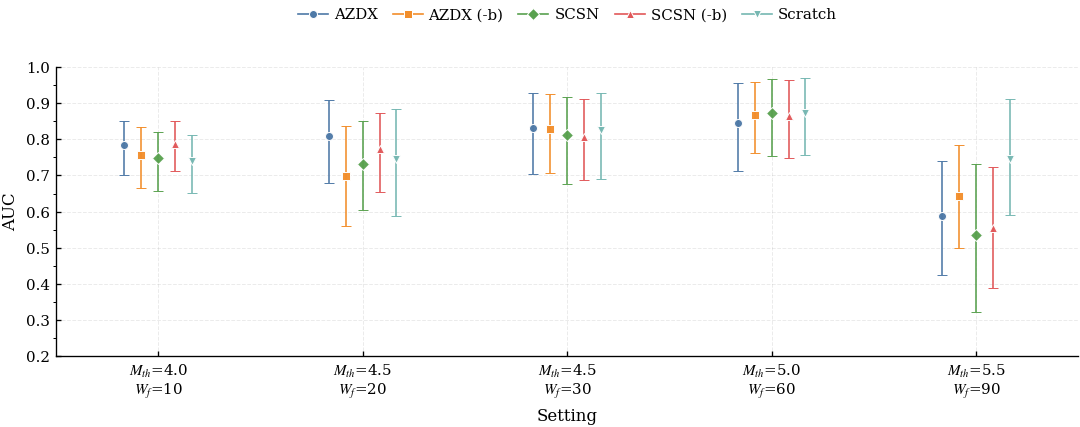

Saved AUC figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/classifier_pretrain_comparison/mean/auc_multi_window_pretrain_cmp.pdf


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src.utils.plot_style import apply_publication_style, save_pub_figure, style_axes

apply_publication_style()
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
})

if 'PAPER_MARKERS' not in globals():
    PAPER_MARKERS = ['o', 's', 'D', '^', 'v', 'P', 'X']


# Build AUC summary table from multi_results + bootstrap AUC CI
auc_rows = []
for i, r in enumerate(multi_results):
    auc_result = _metric_bootstrap_result_for_window(
        r,
        metric_name='auc',
        cfg_seed=5100 + i,
    )

    for model_name in r['models'].keys():
        point_auc = float(r['models'][model_name]['metrics']['auc'])
        auc_ci = auc_result.model_results[model_name]
        auc_rows.append(
            {
                'window_id': int(r['window_id']),
                'Mf': float(r['Mf']),
                'Tfore': int(r['Tfore']),
                'model': str(model_name),
                'auc': point_auc,
                'auc_ci_low': float(auc_ci.ci_low),
                'auc_ci_high': float(auc_ci.ci_high),
            }
        )

if not auc_rows:
    raise RuntimeError('No AUC rows available for visualization.')

window_order = [(float(r['Mf']), int(r['Tfore'])) for r in multi_results]
window_labels = [f'$M_{{th}}$={mf:.1f}\n$W_f$={tf}' for mf, tf in window_order]
window_to_x = {window: idx for idx, window in enumerate(window_order)}

model_names = list(EXPERIMENTS.keys())
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
model_to_color = {name: colors[i % len(colors)] for i, name in enumerate(model_names)}
model_to_marker = {name: PAPER_MARKERS[i % len(PAPER_MARKERS)] for i, name in enumerate(model_names)}

offset_scale = min(0.28, 0.09 + 0.015 * len(model_names))
if len(model_names) == 1:
    model_offsets = {model_names[0]: 0.0}
else:
    centered = np.linspace(-1.0, 1.0, len(model_names))
    model_offsets = {name: float(centered[i] * offset_scale) for i, name in enumerate(model_names)}

auc_ylim = metric_ylim(
    auc_rows,
    value_key='auc',
    low_key='auc_ci_low',
    high_key='auc_ci_high',
)

fig_width = min(9.4, max(6.8, 1.45 * len(window_order) + 1.8))
fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3.6), constrained_layout=True)

for row in auc_rows:
    model_name = row['model']
    window_key = (float(row['Mf']), int(row['Tfore']))
    x_base = window_to_x[window_key]
    x = x_base + model_offsets[model_name]

    y = float(row['auc'])
    yerr_low = max(0.0, y - float(row['auc_ci_low']))
    yerr_high = max(0.0, float(row['auc_ci_high']) - y)

    ax.errorbar(
        x,
        y,
        yerr=np.asarray([[yerr_low], [yerr_high]], dtype=np.float64),
        fmt=model_to_marker[model_name],
        markersize=4.8,
        capsize=2.8,
        elinewidth=1.0,
        color=model_to_color[model_name],
        markerfacecolor=model_to_color[model_name],
        markeredgecolor='white',
        markeredgewidth=0.6,
        alpha=0.96,
        zorder=3,
    )

for model_name in model_names:
    rows_m = [r for r in auc_rows if r['model'] == model_name]
    rows_m = sorted(rows_m, key=lambda r: window_to_x[(float(r['Mf']), int(r['Tfore']))])
    xs = [window_to_x[(float(r['Mf']), int(r['Tfore']))] + model_offsets[model_name] for r in rows_m]
    ys = [float(r['auc']) for r in rows_m]
    # ax.plot(xs, ys, color=model_to_color[model_name], linewidth=1.0, alpha=0.80, zorder=2)

ax.set_xticks(np.arange(len(window_order), dtype=np.int64))
ax.set_xticklabels(window_labels)
ax.set_xlim(-0.5, len(window_order) - 0.5)
style_metric_axis(ax, ylabel='AUC', ylim=auc_ylim, xlabel='Setting', style_axes_fn=style_axes)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=model_to_color[name],
        marker=model_to_marker[name],
        linestyle='-',
        lw=1.0,
        markersize=4.8,
        markerfacecolor=model_to_color[name],
        markeredgecolor='white',
        markeredgewidth=0.6,
        label=name,
    )
    for name in model_names
]
ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=min(len(model_names), 5),
    frameon=False,
    handletextpad=0.4,
    columnspacing=1.0,
)

auc_fig_pdf_path = save_pub_figure(
    fig,
    FIG_EXPORT_DIR / f'auc_multi_window_{EXPORT_LABEL}',
    file_format='pdf',
)
plt.show()

print(f'Saved AUC figure (PDF): {auc_fig_pdf_path}')

## 6) AUC Faceted Plot (2 x 3)


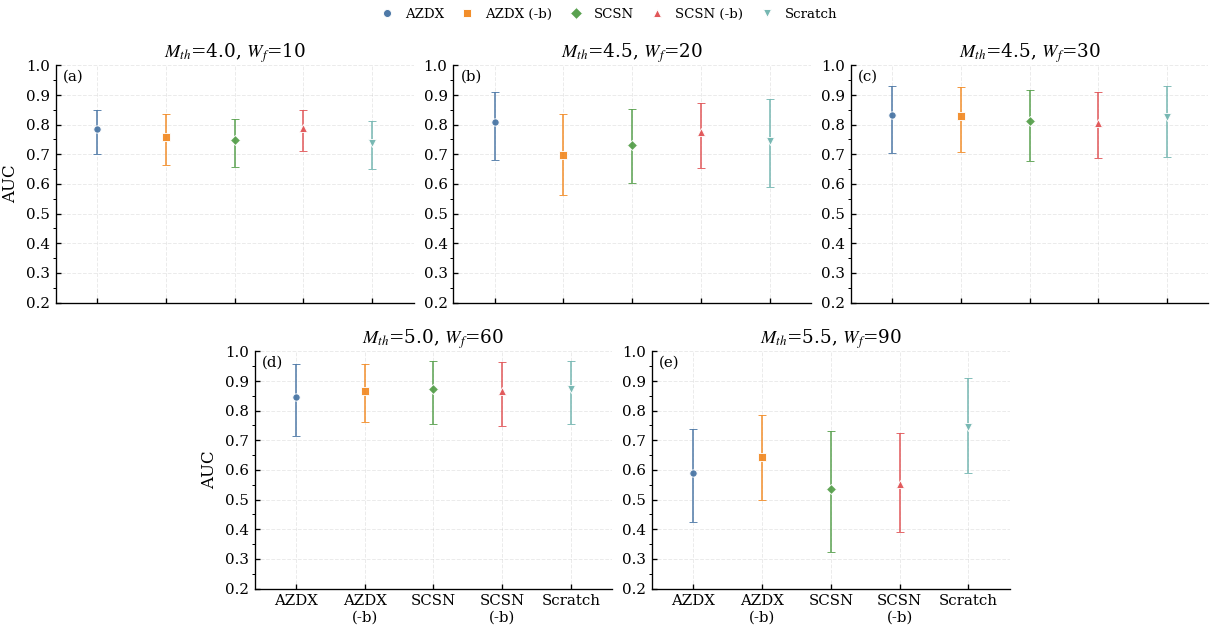

Saved AUC faceted figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/classifier_pretrain_comparison/mean/auc_facet_windows_pretrain_cmp_2x3.pdf


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src.utils.plot_style import apply_publication_style, save_pub_figure, style_axes

apply_publication_style()
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
})

if 'PAPER_MARKERS' not in globals():
    PAPER_MARKERS = ['o', 's', 'D', '^', 'v', 'P', 'X']

# Reuse auc_rows/model_names/model_to_color/window_order from Section 5.
# If Section 5 was not run, rebuild the needed AUC rows first.
if 'auc_rows' not in globals() or len(auc_rows) == 0:
    auc_rows = []
    for i, r in enumerate(multi_results):
        auc_result = _metric_bootstrap_result_for_window(
            r,
            metric_name='auc',
            cfg_seed=5100 + i,
        )
        for model_name in r['models'].keys():
            point_auc = float(r['models'][model_name]['metrics']['auc'])
            auc_ci = auc_result.model_results[model_name]
            auc_rows.append(
                {
                    'window_id': int(r['window_id']),
                    'Mf': float(r['Mf']),
                    'Tfore': int(r['Tfore']),
                    'model': str(model_name),
                    'auc': point_auc,
                    'auc_ci_low': float(auc_ci.ci_low),
                    'auc_ci_high': float(auc_ci.ci_high),
                }
            )

model_names = list(EXPERIMENTS.keys())
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
model_to_color = {name: colors[i % len(colors)] for i, name in enumerate(model_names)}
model_to_marker = {name: PAPER_MARKERS[i % len(PAPER_MARKERS)] for i, name in enumerate(model_names)}

window_order = [(float(r['Mf']), int(r['Tfore'])) for r in multi_results]
window_labels = [f'$M_{{th}}$={mf:.1f}, $W_f$={tf}' for mf, tf in window_order]
window_to_rows = {}
for wf in window_order:
    window_to_rows[wf] = [
        row for row in auc_rows
        if float(row['Mf']) == float(wf[0]) and int(row['Tfore']) == int(wf[1])
    ]

auc_ylim = metric_ylim(
    auc_rows,
    value_key='auc',
    low_key='auc_ci_low',
    high_key='auc_ci_high',
)

n_windows = len(window_order)
n_cols = min(3, max(1, n_windows))
n_rows = int(np.ceil(n_windows / n_cols))
panel_labels = [f'({chr(ord("a") + i)})' for i in range(n_rows * n_cols)]

x_positions = np.arange(len(model_names), dtype=np.float64)
model_tick_labels = [name.replace(' (-b)', '\n(-b)') for name in model_names]

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.45 * n_cols, 2.70 * n_rows),
    squeeze=False,
    constrained_layout=False,
)
axes_flat = axes.ravel()

for i, ax in enumerate(axes_flat):
    if i >= len(window_order):
        ax.axis('off')
        continue

    wf = window_order[i]
    rows_w = window_to_rows[wf]
    if not rows_w:
        ax.axis('off')
        continue

    row_by_model = {row['model']: row for row in rows_w}

    for j, model_name in enumerate(model_names):
        if model_name not in row_by_model:
            continue
        row = row_by_model[model_name]
        y = float(row['auc'])
        yerr_low = max(0.0, y - float(row['auc_ci_low']))
        yerr_high = max(0.0, float(row['auc_ci_high']) - y)

        ax.errorbar(
            x_positions[j],
            y,
            yerr=np.asarray([[yerr_low], [yerr_high]], dtype=np.float64),
            fmt=model_to_marker[model_name],
            markersize=4.4,
            capsize=2.5,
            elinewidth=0.95,
            color=model_to_color[model_name],
            markerfacecolor=model_to_color[model_name],
            markeredgecolor='white',
            markeredgewidth=0.55,
            alpha=0.96,
        )

    ax.set_xlim(-0.6, len(model_names) - 0.4)
    ax.set_xticks(x_positions)
    if (i // n_cols) == (n_rows - 1):
        ax.set_xticklabels(model_tick_labels, rotation=0, ha='center')
    else:
        ax.set_xticklabels([])

    ylabel = 'AUC' if (i % n_cols) == 0 else ''
    style_metric_axis(ax, ylabel=ylabel, ylim=auc_ylim, style_axes_fn=style_axes)

    ax.text(
        0.02,
        0.98,
        panel_labels[i],
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9.0,
    )
    ax.set_title(window_labels[i], pad=4.2)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=model_to_color[name],
        marker=model_to_marker[name],
        linestyle='None',
        markersize=4.8,
        markerfacecolor=model_to_color[name],
        markeredgecolor='white',
        markeredgewidth=0.55,
        label=name,
    )
    for name in model_names
]
legend_ncol = max(1, len(legend_handles))
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=legend_ncol,
    frameon=False,
    bbox_to_anchor=(0.5, 0.988),
    borderaxespad=0.0,
    handletextpad=0.35,
    columnspacing=0.75,
    labelspacing=0.25,
    fontsize=8.0,
)

fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.955], w_pad=0.6, h_pad=1.0)

filled_last_row = n_windows % n_cols
if n_rows > 1 and 0 < filled_last_row < n_cols:
    last_row_start = (n_rows - 1) * n_cols
    last_row_slot_axes = [
        axes_flat[last_row_start + j]
        for j in range(n_cols)
        if (last_row_start + j) < len(axes_flat)
    ]
    row_axes = last_row_slot_axes[:filled_last_row]
    slot_positions = [ax.get_position() for ax in last_row_slot_axes]
    row_left = slot_positions[0].x0
    row_right = slot_positions[-1].x1
    gap = (slot_positions[1].x0 - slot_positions[0].x1) if len(slot_positions) > 1 else 0.0
    widths = [ax.get_position().width for ax in row_axes]
    occupied_width = sum(widths) + gap * max(0, filled_last_row - 1)
    start_x = row_left + max(0.0, (row_right - row_left - occupied_width) / 2.0)

    x_cursor = start_x
    for ax, width in zip(row_axes, widths):
        pos = ax.get_position()
        ax.set_position([x_cursor, pos.y0, width, pos.height])
        x_cursor += width + gap

    for ax in last_row_slot_axes[filled_last_row:]:
        ax.remove()

auc_facet_pdf_path = save_pub_figure(
    fig,
    FIG_EXPORT_DIR / f'auc_facet_windows_{EXPORT_LABEL}_2x3',
    file_format='pdf',
)
plt.show()

print(f'Saved AUC faceted figure (PDF): {auc_facet_pdf_path}')

## 7) PR AUC Visualization (Multi-Window + Faceted 2 x 3)


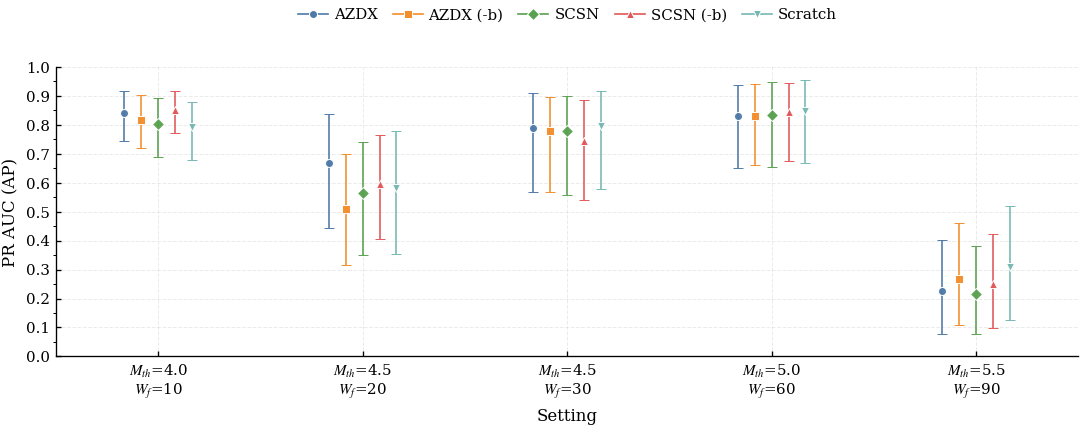

Saved PR AUC figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/classifier_pretrain_comparison/mean/pr_auc_multi_window_pretrain_cmp.pdf


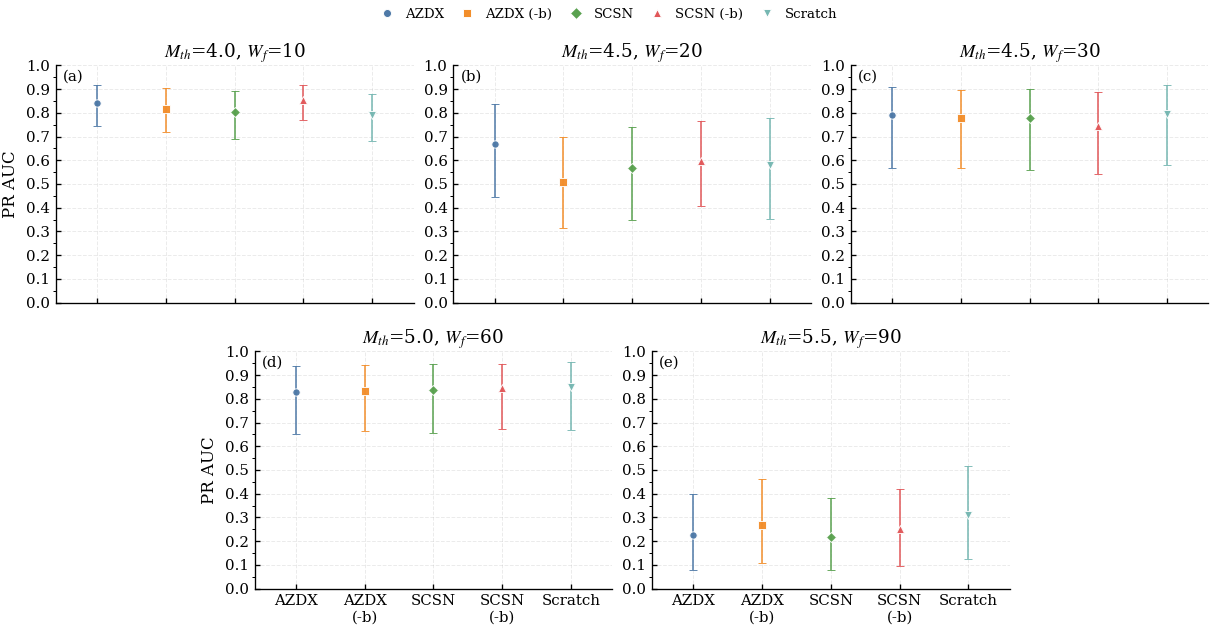

Saved PR AUC faceted figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/classifier_pretrain_comparison/mean/pr_auc_facet_windows_pretrain_cmp_2x3.pdf


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src.utils.plot_style import apply_publication_style, save_pub_figure, style_axes

apply_publication_style()
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
})

if 'PAPER_MARKERS' not in globals():
    PAPER_MARKERS = ['o', 's', 'D', '^', 'v', 'P', 'X']

# Build PR AUC summary rows from multi_results + bootstrap AP CI
pr_rows = []
for i, r in enumerate(multi_results):
    ap_result = _metric_bootstrap_result_for_window(
        r,
        metric_name='ap',
        cfg_seed=6100 + i,
    )

    for model_name in r['models'].keys():
        point_ap = float(r['models'][model_name]['metrics_seed_mean']['pr_auc'])
        ap_ci = ap_result.model_results[model_name]
        pr_rows.append(
            {
                'window_id': int(r['window_id']),
                'Mf': float(r['Mf']),
                'Tfore': int(r['Tfore']),
                'model': str(model_name),
                'ap': point_ap,
                'ap_ci_low': float(ap_ci.ci_low),
                'ap_ci_high': float(ap_ci.ci_high),
            }
        )

if not pr_rows:
    raise RuntimeError('No PR AUC rows available for visualization.')

window_order = [(float(r['Mf']), int(r['Tfore'])) for r in multi_results]
window_labels = [f'$M_{{th}}$={mf:.1f}\n$W_f$={tf}' for mf, tf in window_order]
window_to_x = {window: idx for idx, window in enumerate(window_order)}

model_names = list(EXPERIMENTS.keys())
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
model_to_color = {name: colors[i % len(colors)] for i, name in enumerate(model_names)}
model_to_marker = {name: PAPER_MARKERS[i % len(PAPER_MARKERS)] for i, name in enumerate(model_names)}

offset_scale = min(0.28, 0.09 + 0.015 * len(model_names))
if len(model_names) == 1:
    model_offsets = {model_names[0]: 0.0}
else:
    centered = np.linspace(-1.0, 1.0, len(model_names))
    model_offsets = {name: float(centered[i] * offset_scale) for i, name in enumerate(model_names)}

pr_ylim = metric_ylim(
    pr_rows,
    value_key='ap',
    low_key='ap_ci_low',
    high_key='ap_ci_high',
)

# -------- PR AUC overview --------
fig_width = min(9.4, max(6.8, 1.45 * len(window_order) + 1.8))
fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3.6), constrained_layout=True)

for row in pr_rows:
    model_name = row['model']
    window_key = (float(row['Mf']), int(row['Tfore']))
    x_base = window_to_x[window_key]
    x = x_base + model_offsets[model_name]

    y = float(row['ap'])
    yerr_low = max(0.0, y - float(row['ap_ci_low']))
    yerr_high = max(0.0, float(row['ap_ci_high']) - y)

    ax.errorbar(
        x,
        y,
        yerr=np.asarray([[yerr_low], [yerr_high]], dtype=np.float64),
        fmt=model_to_marker[model_name],
        markersize=4.8,
        capsize=2.8,
        elinewidth=1.0,
        color=model_to_color[model_name],
        markerfacecolor=model_to_color[model_name],
        markeredgecolor='white',
        markeredgewidth=0.6,
        alpha=0.96,
        zorder=3,
    )

for model_name in model_names:
    rows_m = [r for r in pr_rows if r['model'] == model_name]
    rows_m = sorted(rows_m, key=lambda r: window_to_x[(float(r['Mf']), int(r['Tfore']))])
    xs = [window_to_x[(float(r['Mf']), int(r['Tfore']))] + model_offsets[model_name] for r in rows_m]
    ys = [float(r['ap']) for r in rows_m]
    # ax.plot(xs, ys, color=model_to_color[model_name], linewidth=1.0, alpha=0.80, zorder=2)

ax.set_xticks(np.arange(len(window_order), dtype=np.int64))
ax.set_xticklabels(window_labels)
ax.set_xlim(-0.5, len(window_order) - 0.5)
style_metric_axis(ax, ylabel='PR AUC (AP)', ylim=pr_ylim, xlabel='Setting', style_axes_fn=style_axes)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=model_to_color[name],
        marker=model_to_marker[name],
        linestyle='-',
        lw=1.0,
        markersize=4.8,
        markerfacecolor=model_to_color[name],
        markeredgecolor='white',
        markeredgewidth=0.6,
        label=name,
    )
    for name in model_names
]
ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=min(len(model_names), 5),
    frameon=False,
    handletextpad=0.4,
    columnspacing=1.0,
)

pr_fig_pdf_path = save_pub_figure(
    fig,
    FIG_EXPORT_DIR / f'pr_auc_multi_window_{EXPORT_LABEL}',
    file_format='pdf',
)
plt.show()

print(f'Saved PR AUC figure (PDF): {pr_fig_pdf_path}')

# -------- PR AUC faceted 2x3 --------
window_to_pr_rows = {}
for wf in window_order:
    window_to_pr_rows[wf] = [
        row for row in pr_rows
        if float(row['Mf']) == float(wf[0]) and int(row['Tfore']) == int(wf[1])
    ]

n_windows = len(window_order)
n_cols = min(3, max(1, n_windows))
n_rows = int(np.ceil(n_windows / n_cols))
panel_labels = [f'({chr(ord("a") + i)})' for i in range(n_rows * n_cols)]
x_positions = np.arange(len(model_names), dtype=np.float64)
model_tick_labels = [name.replace(' (-b)', '\n(-b)') for name in model_names]

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.45 * n_cols, 2.70 * n_rows),
    squeeze=False,
    constrained_layout=False,
)
axes_flat = axes.ravel()

for i, ax in enumerate(axes_flat):
    if i >= len(window_order):
        ax.axis('off')
        continue

    wf = window_order[i]
    rows_w = window_to_pr_rows[wf]
    if not rows_w:
        ax.axis('off')
        continue

    row_by_model = {row['model']: row for row in rows_w}

    for j, model_name in enumerate(model_names):
        if model_name not in row_by_model:
            continue
        row = row_by_model[model_name]
        y = float(row['ap'])
        yerr_low = max(0.0, y - float(row['ap_ci_low']))
        yerr_high = max(0.0, float(row['ap_ci_high']) - y)

        ax.errorbar(
            x_positions[j],
            y,
            yerr=np.asarray([[yerr_low], [yerr_high]], dtype=np.float64),
            fmt=model_to_marker[model_name],
            markersize=4.4,
            capsize=2.5,
            elinewidth=0.95,
            color=model_to_color[model_name],
            markerfacecolor=model_to_color[model_name],
            markeredgecolor='white',
            markeredgewidth=0.55,
            alpha=0.96,
        )

    ax.set_xlim(-0.6, len(model_names) - 0.4)
    ax.set_xticks(x_positions)
    if (i // n_cols) == (n_rows - 1):
        ax.set_xticklabels(model_tick_labels, rotation=0, ha='center')
    else:
        ax.set_xticklabels([])

    ylabel = 'PR AUC' if (i % n_cols) == 0 else ''
    style_metric_axis(ax, ylabel=ylabel, ylim=pr_ylim, style_axes_fn=style_axes)

    ax.text(
        0.02,
        0.98,
        panel_labels[i],
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9.0,
    )
    ax.set_title(window_labels[i].replace('\n', ', '), pad=4.2)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=model_to_color[name],
        marker=model_to_marker[name],
        linestyle='None',
        markersize=4.8,
        markerfacecolor=model_to_color[name],
        markeredgecolor='white',
        markeredgewidth=0.55,
        label=name,
    )
    for name in model_names
]
legend_ncol = max(1, len(legend_handles))
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=legend_ncol,
    frameon=False,
    bbox_to_anchor=(0.5, 0.988),
    borderaxespad=0.0,
    handletextpad=0.35,
    columnspacing=0.75,
    labelspacing=0.25,
    fontsize=8.0,
)

fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.955], w_pad=0.6, h_pad=1.0)

filled_last_row = n_windows % n_cols
if n_rows > 1 and 0 < filled_last_row < n_cols:
    last_row_start = (n_rows - 1) * n_cols
    last_row_slot_axes = [
        axes_flat[last_row_start + j]
        for j in range(n_cols)
        if (last_row_start + j) < len(axes_flat)
    ]
    row_axes = last_row_slot_axes[:filled_last_row]
    slot_positions = [ax.get_position() for ax in last_row_slot_axes]
    row_left = slot_positions[0].x0
    row_right = slot_positions[-1].x1
    gap = (slot_positions[1].x0 - slot_positions[0].x1) if len(slot_positions) > 1 else 0.0
    widths = [ax.get_position().width for ax in row_axes]
    occupied_width = sum(widths) + gap * max(0, filled_last_row - 1)
    start_x = row_left + max(0.0, (row_right - row_left - occupied_width) / 2.0)

    x_cursor = start_x
    for ax, width in zip(row_axes, widths):
        pos = ax.get_position()
        ax.set_position([x_cursor, pos.y0, width, pos.height])
        x_cursor += width + gap

    for ax in last_row_slot_axes[filled_last_row:]:
        ax.remove()

pr_facet_pdf_path = save_pub_figure(
    fig,
    FIG_EXPORT_DIR / f'pr_auc_facet_windows_{EXPORT_LABEL}_2x3',
    file_format='pdf',
)
plt.show()

print(f'Saved PR AUC faceted figure (PDF): {pr_facet_pdf_path}')

## 8) Export metrics (long + pairwise delta + json)



In [8]:
print(f"Export threshold mode: {THRESHOLD_SELECTION_MODE} (opt_metric={THRESHOLD_OPTIMIZE_METRIC})")

export_artifacts = run_classification_bootstrap_export_pipeline(
    multi_results=multi_results,
    bootstrap_preset=BOOTSTRAP_PRESET,
    round_fn=_r4,
    threshold_optimize_metric=THRESHOLD_OPTIMIZE_METRIC,
    use_hierarchical_seed_sample=USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP,
    export_dir=EXPORT_DIR,
    export_stem=EXPORT_STEM,
    export_label=EXPORT_LABEL,
    round_decimals=ROUND_DECIMALS,
    seed_aggregation=SEED_AGG_METHOD,
    point_estimate_mode=BOOTSTRAP_POINT_ESTIMATE_MODE,
    baseline_model=BASELINE_MODEL,
    sort_export_by=SORT_EXPORT_BY,
    sort_delta_by=SORT_DELTA_BY,
    window_model_rows_getter=lambda r: r['models'],
    metadata={
        'dataset': 'classifier_pretrain_comparison',
        'seeds': [int(s) for s in ACTIVE_SEEDS],
        'bootstrap_selected_seeds': (
            [int(s) for s in BOOTSTRAP_SELECTED_SEEDS]
            if BOOTSTRAP_SELECTED_SEEDS is not None
            else None
        ),
        'point_metric_mode': 'seed_mean',
        'seed_aggregation_method': str(SEED_AGG_METHOD),
        'seedwise_mean_metrics': True,
        'model_names': list(EXPERIMENTS.keys()),
        'threshold_selection_mode': THRESHOLD_SELECTION_MODE,
    },
)

render_classification_bootstrap_export(export_artifacts)
print(f"Export completed with threshold mode: {THRESHOLD_SELECTION_MODE}")
summary_by_model = export_artifacts.summary_by_model
metrics_rows = export_artifacts.metrics_rows
delta_rows = export_artifacts.delta_rows
metrics_csv_path = export_artifacts.metrics_csv_path
deltas_csv_path = export_artifacts.deltas_csv_path
metrics_json_path = export_artifacts.metrics_json_path
summary_by_model


Bootstrap long CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/mean/clf_ci_long_pretrain_cmp.csv
Bootstrap pairwise delta CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/mean/clf_ci_pairwise_delta_pretrain_cmp.csv
Bootstrap JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_pretrain_comparison/mean/clf_ci_long_pretrain_cmp.json
Exported rows: metrics=25, deltas=20


,Mf,Tfore,model,auc,auc_point_estimate_std,ap,ap_point_estimate_std,auc_ci_low,auc_ci_high,ap_ci_low,ap_ci_high
0,4.0,10,AZDX,0.7846,0.0477,0.8426,0.0658,0.7031,0.8526,0.7557,0.9126
1,4.0,10,AZDX (-b),0.7579,0.0823,0.8154,0.0977,0.6623,0.8344,0.7109,0.9040
2,4.0,10,SCSN,0.7471,0.0764,0.8028,0.0937,0.6550,0.8212,0.6957,0.9001
3,4.0,10,SCSN (-b),0.7881,0.0202,0.8523,0.0323,0.7063,0.8504,0.7647,0.9180
4,4.0,10,Scratch,0.7387,0.0446,0.7917,0.0610,0.6451,0.8116,0.6954,0.8814
5,4.5,20,AZDX,0.8085,0.0373,0.6673,0.0321,0.6678,0.9140,0.4262,0.8403
6,4.5,20,AZDX (-b),0.6977,0.1514,0.5077,0.1704,0.5697,0.8269,0.2984,0.7060
7,4.5,20,SCSN,0.7324,0.0765,0.5653,0.1117,0.6032,0.8543,0.3405,0.7542
8,4.5,20,SCSN (-b),0.7746,0.0564,0.5955,0.0942,0.6601,0.8769,0.3736,0.7784
9,4.5,20,Scratch,0.7464,0.1696,0.5815,0.1655,0.5954,0.8892,0.3451,0.7862


{'AZDX': {'mean_threshold': 0.482,
  'mean_f1': 0.62,
  'mean_recall': 0.7283,
  'mean_precision': 0.5999,
  'mean_r': 0.4621,
  'mean_auc': 0.7717,
  'std_auc': 0.1045,
  'mean_ap': 0.6711,
  'std_ap': 0.2581,
  'num_windows': 5},
 'AZDX (-b)': {'mean_threshold': 0.4783,
  'mean_f1': 0.6056,
  'mean_recall': 0.7721,
  'mean_precision': 0.5451,
  'mean_r': 0.4216,
  'mean_auc': 0.7589,
  'std_auc': 0.0917,
  'mean_ap': 0.6404,
  'std_ap': 0.2458,
  'num_windows': 5},
 'SCSN': {'mean_threshold': 0.4796,
  'mean_f1': 0.6089,
  'mean_recall': 0.7452,
  'mean_precision': 0.5724,
  'mean_r': 0.4257,
  'mean_auc': 0.7398,
  'std_auc': 0.1269,
  'mean_ap': 0.6392,
  'std_ap': 0.2595,
  'num_windows': 5},
 'SCSN (-b)': {'mean_threshold': 0.4869,
  'mean_f1': 0.6205,
  'mean_recall': 0.7455,
  'mean_precision': 0.5918,
  'mean_r': 0.4505,
  'mean_auc': 0.7579,
  'std_auc': 0.119,
  'mean_ap': 0.6576,
  'std_ap': 0.25,
  'num_windows': 5},
 'Scratch': {'mean_threshold': 0.485,
  'mean_f1': 0.645